In [ ]:
using PlotlyJS
using Infiltrator
using XLSX
using CSV
include("./processing.jl")
include("../model/utils/empirical_mu.jl")


solve_empirical_μ_get_solution (generic function with 1 method)

In [ ]:
day = 7
input_folder = "../input/base_case_increased_storage_energy_v8.0.8.4.1"
ε = 0.025
ρ = 0.8
gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve = load_deterministic_data(day, input_folder, ε, ρ)
required_energy_reserve = load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df, ε, ρ)
;

Reserve file found, loading reserves...
Energy reserve file found, loading reserves...


Checking that max_{i in T} ER[s,i,t]<=sum(R[S,τ], τ<=t) 

In [ ]:
max_required_energy_reserve = combine(groupby(required_energy_reserve, [:t_hour]),[:reserve_up_MW, :reserve_down_MW].=> maximum, renamecols = false)
rename!(max_required_energy_reserve,:t_hour => :hour)
cumsum_required_reserve = combine(required_reserve, [:reserve_up_MW, :reserve_down_MW] .=> cumsum, renamecols = false)
# cumsum_required_reserve.hour .= required_reserve.hour
# cumsum_required_reserve = required_reserve[:, [:hour, :reserve_up_MW, :reserve_down_MW]] .|> cumsum 
delta_reserve = cumsum_required_reserve[:, [:reserve_up_MW, :reserve_down_MW]] .- max_required_energy_reserve[:, [:reserve_up_MW, :reserve_down_MW]]
delta_reserve.hour .= required_reserve.hour
all.(delta_reserve[:,[:reserve_up_MW, :reserve_down_MW]] .>=0)


Row,reserve_up_MW,reserve_down_MW
,Bool,Bool
1,true,true
2,true,true
3,true,true
4,true,true
5,true,true
6,true,true
7,true,true
8,true,true
9,true,true


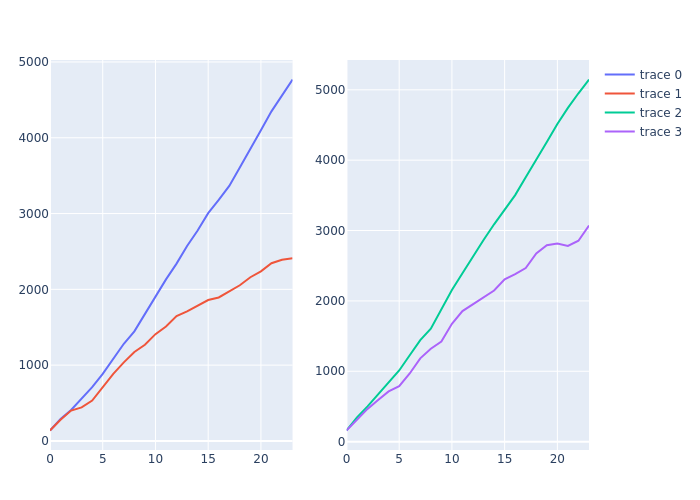

In [ ]:
s1 = scatter(cumsum_required_reserve, y = :reserve_up_MW)
s2 = scatter(max_required_energy_reserve, y = :reserve_up_MW)
p1 = plot([s1;s2])

s1 = scatter(cumsum_required_reserve, y = :reserve_down_MW)
s2 = scatter(max_required_energy_reserve, y = :reserve_down_MW)
p2 = plot([s1;s2])
[p1 p2]

# plot(stack(delta_reserve, [:reserve_up_MW, :reserve_down_MW]), x = :hour, y = :value, group = :variable)

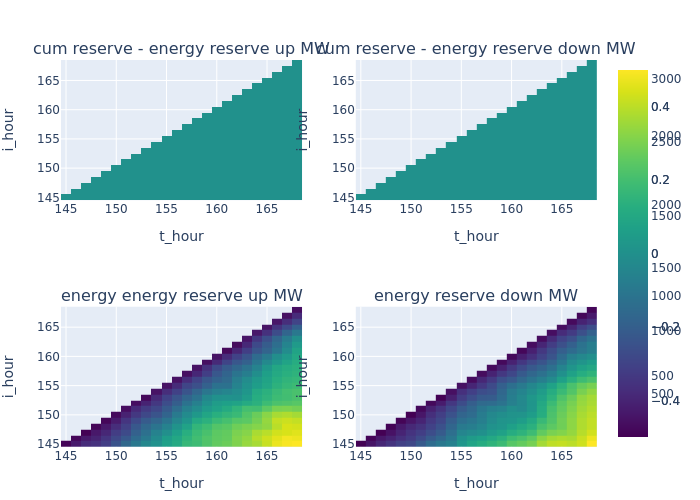

In [ ]:
cumsum_required_reserve = required_energy_reserve[:,[:i_hour,:t_hour]] # cumualtive required reserve between i and t
f(i,t,df) = 
    (reserve_up_MW = sum(df[(df.hour.>=i).&&(df.hour.<=t),:reserve_up_MW]),
    reserve_down_MW = sum(df[(df.hour.>=i).&&(df.hour.<=t),:reserve_down_MW]),
    )
transform!(groupby(cumsum_required_reserve,[:i_hour, :t_hour]), [:i_hour, :t_hour] => ((i,t) -> f(i,t,required_reserve)) => AsTable)
;
# delta with energy reserve. 
delta = cumsum_required_reserve[:, [:reserve_up_MW, :reserve_down_MW]] .- required_energy_reserve[:, [:reserve_up_MW, :reserve_down_MW]]
delta.i_hour .= cumsum_required_reserve.i_hour
delta.t_hour .= cumsum_required_reserve.t_hour
delta[delta.reserve_up_MW .>=0,:reserve_up_MW].= 0
delta[delta.reserve_down_MW .>=0,:reserve_down_MW].= 0
# delta = filter(row -> all(x -> x <= 0, row[[:reserve_up_MW, :reserve_down_MW]]), delta)
;
p1 = PlotlyJS.plot(heatmap(x=delta.t_hour, y=delta.i_hour, z=delta.reserve_up_MW, colorscale="Viridis"), Layout(title="cum reserve - energy reserve up MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p2 = PlotlyJS.plot(heatmap(x=delta.t_hour, y=delta.i_hour, z=delta.reserve_down_MW, colorscale="Viridis"), Layout(title="cum reserve - energy reserve down MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p3 = PlotlyJS.plot(heatmap(x=required_energy_reserve.t_hour, y=required_energy_reserve.i_hour, z=required_energy_reserve.reserve_up_MW, colorscale="Viridis"), Layout(title="energy energy reserve up MW", xaxis_title="t_hour", yaxis_title="i_hour"))
p4 = PlotlyJS.plot(heatmap(x=required_energy_reserve.t_hour, y=required_energy_reserve.i_hour, z=required_energy_reserve.reserve_down_MW, colorscale="Viridis"), Layout(title="energy reserve down MW", xaxis_title="t_hour", yaxis_title="i_hour"))
# p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNDIS, colorscale="Viridis"))
# p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.sDNCH, colorscale="Viridis"))
[p1 p2; p3 p4]

In [ ]:
temportal_weights = false
model, sol_1, sol_2 = solve_empirical_µ_get_solution(gen_df, loads_multi_df, storage_df, required_reserve, required_energy_reserve; temportal_weights = temportal_weights)
# sol_1 = dropmissing(sol_1)
;


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2475843
Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Set parameter MIPGap to value 1e-06
Set parameter MIPGap to value 1e-06
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 11th Gen Intel(R) Core(TM) i7-11370H @ 3.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Optimize a model with 3888 rows, 2932 columns and 18176 nonzeros
Model fingerprint: 0x00ee8c13
Model has 96 quadratic objective terms
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 3e+03]
Presolve removed 1912 rows and 2028 columns
Presolve time: 0.01s
Pr

In [ ]:
sol_1

Row,r_id,t,RESUP,RESDN,RESUPDIS,RESUPCH,RESDNCH,RESDNDIS,SOEUP,SOEDN,MAXERESUPDIS,MAXERESUPCH,MAXERESDNCH,MAXERESDNDIS,εUPDIS,εUPCH,εDNCH,εDNDIS,θUPDIS,θUPCH,θDNCH,θDNDIS
,Int64,Int64,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,101,145,137.839,158.496,68.6297,69.209,78.1202,80.3762,0.0,0.0,68.6297,69.209,78.1202,80.3762,0.0,0.0,0.0,0.0,68.6297,69.209,78.1202,80.3762
2,101,146,151.751,187.473,75.533,76.2183,93.7117,93.7617,0.0,0.0,143.337,144.602,169.518,171.711,0.0,0.0,0.0,0.0,74.7074,75.3935,91.3973,91.3349
3,101,147,119.137,154.442,57.0474,62.09,74.855,79.5873,0.0,0.0,199.371,205.673,241.645,248.396,0.0,0.0,0.0,0.0,56.0336,61.0705,72.1276,76.6848
4,101,148,148.309,172.043,73.2892,75.0196,84.8048,87.238,0.0,0.0,268.123,276.998,322.363,332.245,0.0,0.0,0.0,0.0,68.7522,71.3247,80.7177,83.8494
5,101,149,152.24,182.863,74.6993,77.5409,90.8313,92.0316,0.0,0.0,338.389,351.495,408.936,421.196,0.000357408,0.000355877,0.000350279,0.000352402,70.2665,74.4981,86.5733,88.9509
6,101,150,175.602,155.902,86.8599,88.7425,74.8986,81.0037,0.0,0.0,421.269,436.547,479.525,498.174,0.000356878,0.000355155,0.000355964,0.000358208,82.8795,85.0513,70.5892,76.978
7,101,151,195.462,215.94,97.0424,98.4196,107.959,107.981,0.0,0.0,513.141,528.325,582.421,599.861,0.000355523,0.000353153,0.000355142,0.000357175,91.8721,91.7783,102.896,101.687
8,101,152,201.691,215.163,100.481,101.21,106.874,108.289,0.0,0.0,605.714,622.313,682.429,701.951,0.000354286,0.000351927,0.000349356,0.000351905,92.573,93.9879,100.008,102.089
9,101,153,163.316,161.752,78.2796,85.0366,76.2855,85.467,0.0,0.0,675.501,699.368,751.487,780.511,0.000351536,0.000349439,0.000351309,0.000355478,69.7878,77.0555,69.0581,78.5606


In [ ]:
println(value(model[:epsilon_variance]))
println(value(model[:theta]))
println(value(model[:reserve]))
# println(value(model[:slack]))
println(objective_value(model))

9.448247987230018e-6
5480.883080803672
9914.608608150005
-4433.7255178980795


In [ ]:
function calculate_mu_t(sol_1_)
    sol_1 = dropmissing(sol_1_)
    mu = DataFrame()
    for (θ, RES) in [(:θUPDIS, :RESUPDIS), (:θUPCH, :RESUPCH), (:θDNDIS, :RESDNDIS), (:θDNCH, :RESDNCH)]
        # mu[!, Symbol("$θ/$RES")] = cumsum(sol_1[:, θ]) ./ cumsum(sol_1[:, RES]) # comment this to get cumulative ratio
        mu[!, Symbol("$θ/$RES")] = (sol_1[:, θ]) ./ (sol_1[:, RES])
    end
    mu[!, :t] = sol_1.t
    mu = mu[1:end, :]
    leftjoin!(sol_1, mu, on = :t)
    
    return unstack(stack(mu, Not(:t), variable_name=:mu),:t, :value)
end
mu_t = calculate_mu_t(sol_1)
# mu_t


Row,mu,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168
,String,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,θUPDIS/RESUPDIS,1.0,0.98907,0.982228,0.938095,0.940657,0.954174,0.946721,0.921297,0.891519,0.911371,0.884422,0.827196,0.696767,0.504304,0.260741,0.128749,0.118631,0.0951923,0.0534317,0.0477683,0.0312683,0.0288399,0.0189713,0.0111449
2,θUPCH/RESUPCH,1.0,0.989178,0.983582,0.950748,0.960758,0.958405,0.93252,0.928644,0.906145,0.911057,0.87477,0.803961,0.728972,0.562405,0.283448,0.121649,0.108979,0.0856658,0.0539094,0.0518626,0.0305748,0.0271164,0.0159581,0.00871383
3,θDNDIS/RESDNDIS,1.0,0.974118,0.963531,0.961157,0.966525,0.950303,0.94171,0.942748,0.919192,0.936282,0.918631,0.876538,0.874515,0.845475,0.725781,0.435848,0.235805,0.137542,0.143497,0.0647088,0.0447713,0.048145,0.0350284,0.029232
4,θDNCH/RESDNCH,1.0,0.975303,0.963564,0.951805,0.953122,0.942464,0.953103,0.935756,0.905259,0.937932,0.926956,0.882079,0.839949,0.79246,0.678995,0.42813,0.252757,0.138334,0.137212,0.0638817,0.0458229,0.0515229,0.0403266,0.0349306


┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247


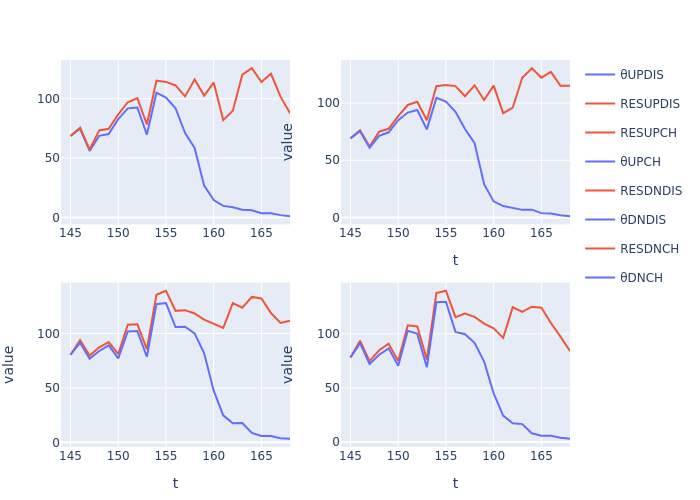

In [ ]:
ks = [:θUPDIS,:RESUPDIS]
s1 = scatter(stack(sol_1, ks), x = :t, y = :value, color=:r_id, group =:variable, facet_col = :r_id)
p1 = plot(s1)
# ks = ["θUPDIS/RESUPDIS"]
# s2 = scatter(stack(sol_1, ks),  x = :t, y = :value, color=:r_id, group =:variable, yaxis="y2")
# p1 = plot([s1; s2], Layout(yaxis2 = attr(overlaying="y", side="right")))

ks = [:θUPCH,:RESUPCH]
p2 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id)

ks = [:θDNDIS,:RESDNDIS]
p3 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id)

ks = [:θDNCH,:RESDNCH]
p4 = plot(stack(sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id)

[p1 p2; p3 p4]

┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247
┌ Warning: One of color or symbol present AND group -- group will be ignored
└ @ PlotlyBase /home/ubuntu/.julia/packages/PlotlyBase/4NWbR/src/dataframes_api.jl:247


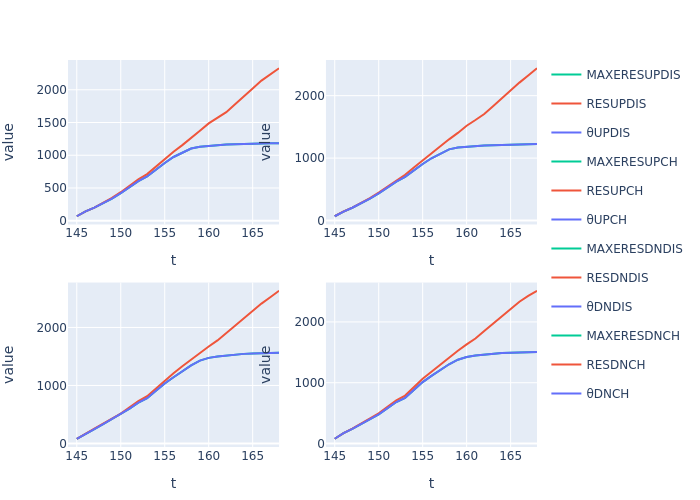

In [ ]:
cumsum_sol_1 = combine(groupby(sol_1, :r_id), [:RESUPDIS, :RESDNDIS, :RESUPCH, :RESDNCH, :θUPDIS, :θUPCH, :θDNCH, :θDNDIS] .=> cumsum, renamecols = false)
cumsum_sol_1.t = unique(sol_1.t)
leftjoin!(cumsum_sol_1, sol_1[:, [:r_id, :t, :MAXERESUPDIS, :MAXERESUPCH, :MAXERESDNCH, :MAXERESDNDIS]], on = [:r_id, :t])

ks = [:θUPDIS,:RESUPDIS,:MAXERESUPDIS]
p1 = plot(stack(cumsum_sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θUPCH,:RESUPCH, :MAXERESUPCH]
p2 = plot(stack(cumsum_sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θDNDIS,:RESDNDIS, :MAXERESDNDIS]
p3 = plot(stack(cumsum_sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

ks = [:θDNCH,:RESDNCH, :MAXERESDNCH]
p4 = plot(stack(cumsum_sol_1, ks), x = :t, y = :value, group=:r_id, color =:variable, facet_col = :r_id, title="Plot for $(ks[1]) and $(ks[2])")

[p1 p2; p3 p4]

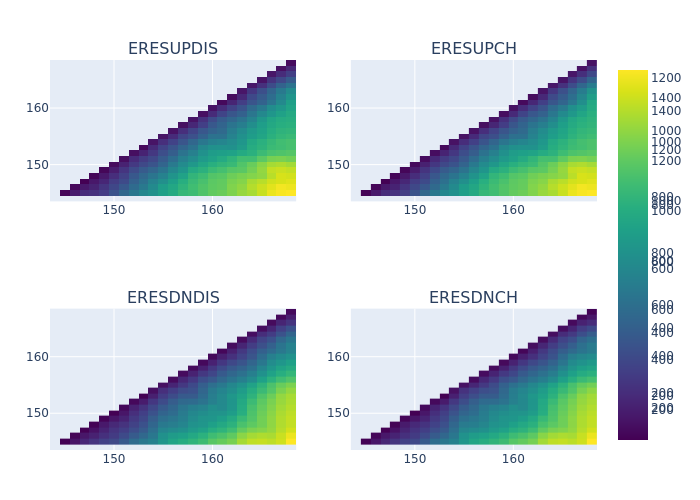

In [ ]:
p1 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESUPDIS, colorscale="Viridis"), Layout(title="ERESUPDIS"))
p2 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESUPCH, colorscale="Viridis"), Layout(title="ERESUPCH"))
p3 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESDNDIS, colorscale="Viridis"), Layout(title="ERESDNDIS"))
p4 = PlotlyJS.plot(heatmap(x=sol_2.t, y=sol_2.i, z=sol_2.ERESDNCH, colorscale="Viridis"), Layout(title="ERESDNCH"))
[p1 p2; p3 p4]

In [ ]:
rhos = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.99]
day = 7
temportal_weights = false
mu_t_all = DataFrame()
for rho in rhos
    input_folder = "../input/base_case_increased_storage_energy_v8.$(rho).4"
    gen_df, loads_multi_df, random_loads_multi_df, gen_variable_multi_df, storage_df, required_reserve = load_deterministic_data(day, input_folder)
    required_energy_reserve = load_energy_reserve(day, input_folder, loads_multi_df, gen_variable_multi_df)
    model, sol_1, sol_2 = solve_empirical_µ_get_solution(gen_df, loads_multi_df, storage_df, required_reserve, required_energy_reserve; temportal_weights = temportal_weights)
    mu_t = calculate_mu_t(sol_1)
    mu_t = insertcols(mu_t, 1, :rho => rho)
    append!(mu_t_all, mu_t)
end
CSV.write("empirical_mu.csv", mu_t_all)
# transform!(mu_t_all, AsTable(Not([:rho, :variable])) => ByRow(x -> mean(x)) => :mean)

Reserve file found, loading reserves...
Energy reserve file found, loading reserves...
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2475843
Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Set parameter MIPGap to value 1e-06
Set parameter MIPGap to value 1e-06
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: 11th Gen Intel(R) Core(TM) i7-11370H @ 3.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Academic license 2475843 - for non-commercial use only - registered to pa___@imperial.ac.uk
Optimize a model with 3888 rows, 2932 columns and 18176 nonzeros
Model fingerprint: 0x587fdeac
Model has 96 quadratic objective terms
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range   

"empirical_mu.csv"